## PRÁCTICA 1

**Aviso: Debido a que se modifica constantemente el dataframe se recomienda ejecutar todos los códigos desde el inicio hacia delante**

1. Importamos las librerías adecuadas: numpy, pandas, matplotlib, seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

2. Vamos a cargar los datos del csv y visualizarlos utilzando la función "read_csv" de pandas. Además, vamos a denominarlo como "data". También vamos a generar "dolo", que será el dataset sin modificar.

In [2]:
data = pd.read_csv("dataset_housing.csv") 
dolo = pd.read_csv("dataset_housing.csv")

In [3]:
import pandas as pd 
df = pd.read_csv("dataset_housing.csv") 
# Calcula la correlación de cada columna numérica con 'target'
correlaciones = df.corr(numeric_only=True)["SalePrice"].abs()
print(correlaciones)
# Selecciona solo las columnas con correlación >= 0.2
columnas_retenidas = correlaciones[correlaciones >= 0.2].index.tolist()
print(columnas_retenidas)
# Añade 'SalePrice' (por si no cumple la condición, para no eliminarla)
if "SalePrice" not in columnas_retenidas:
    columnas_retenidas.append("SalePrice")

# Filtra el DataFrame manteniendo solo esas columnas
df_filtrado = df[columnas_retenidas]


Id               0.021917
MSSubClass       0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond      0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2       0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF     0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath     0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch    0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal          0.021190
MoSold           0.046432
YrSold           0.028923
SalePrice        1.000000
Name: SalePr

In [4]:
#MOSTRAMOS LOS DATOS CON SUS DIFERENTES FILAS Y COLUMNAS
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
#VEMOS LOS TIPOS DE LAS COLUMNAS
data.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [6]:
data.shape

(1460, 81)

Como podemos ver, hay 1460 viviendas o filas en el conjunto de datos con 81 atributos o columnas por cada vivienda. Ahora vamos a ver cuantas columnas tienen valores nulos y ver cuantos tienen por atributo.

In [7]:
for i in df:
    if df[[i]].isnull().sum()[i]> 0:
        print(f'Atributo "{i}", con valores Nulos {df[[i]].isnull().sum()[i]}')

Atributo "LotFrontage", con valores Nulos 259
Atributo "Alley", con valores Nulos 1369
Atributo "MasVnrType", con valores Nulos 872
Atributo "MasVnrArea", con valores Nulos 8
Atributo "BsmtQual", con valores Nulos 37
Atributo "BsmtCond", con valores Nulos 37
Atributo "BsmtExposure", con valores Nulos 38
Atributo "BsmtFinType1", con valores Nulos 37
Atributo "BsmtFinType2", con valores Nulos 38
Atributo "Electrical", con valores Nulos 1
Atributo "FireplaceQu", con valores Nulos 690
Atributo "GarageType", con valores Nulos 81
Atributo "GarageYrBlt", con valores Nulos 81
Atributo "GarageFinish", con valores Nulos 81
Atributo "GarageQual", con valores Nulos 81
Atributo "GarageCond", con valores Nulos 81
Atributo "PoolQC", con valores Nulos 1453
Atributo "Fence", con valores Nulos 1179
Atributo "MiscFeature", con valores Nulos 1406


Ahora que hemos obtenido todos los atributos o columnas con  valores "null" y la cantidad de "null" que hay por columna vamos a realizar un estudio de ciertas variables del conjunto de datos.
### ID

In [8]:
# En primer lugar, vamos a definir la columna como una variable.
id  = data["Id"]
# Print del tipo y de los valores únicos
print(np.unique(id))
print(f"Tipo:{id.dtype}")
# Comprobamos si tiene valores
if id.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    

[   1    2    3 ... 1458 1459 1460]
Tipo:int64
No tiene valores nulos


La variable id es una primary key, por tanto no tiene valores repetidos. Además, no tiene ningún valor null y es de tipo categórico sin orden, ya que simplemente designa una key con la que se la puede identificar respecto de cualquier otra variable. Entonces no se puede obtener su valor mínimo y máximo y tampoco hace falta recodificar la variable al ser una primary key.
### MSSubClass

In [9]:
# Definimos la variable
MSSubClass = data["MSSubClass"]
# Vemos el tipo, los valores únicos y la cantidad que hay de cada uno
print(np.unique(MSSubClass))
print(MSSubClass.value_counts())
# Comprobamos si tiene valores nulos
if MSSubClass.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos") 
# One-hot Encoding    
data = pd.get_dummies(data, columns = ["MSSubClass"])

[ 20  30  40  45  50  60  70  75  80  85  90 120 160 180 190]
MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64
No tiene valores nulos


Es una variable que indica el tipo de vivienda. Es una variable que es de tipo categórico con orden,ya que según mayor sea el número mayor relevancia tendrá a la hora de analizarse. Por tanto, no se puede hallar ni su mínimo ni su máximo pero si podemos saber cual es el tipo de vivienda que más se repite (20___1-STORY 1946 & NEWER ALL STYLES) y la que menos (40___1-1/2 STORY - UNFINISHED ALL AGES). Además, no tiene valores nulos y se ve que tiene unos valores únicos que designan el tipo de la casa como podemos ver en el documento de la descripción de los datos. Vamos a codificar esta variable categórica mediante el proceso de "One-hot encoding", permitiendo que los modelos numéricos interpreten correctamente esta variable categórica sin imponer orden entre sus valores.
### MSZoning

In [10]:
# Definimos la variable
MSZoning = data["MSZoning"]
print(np.unique(MSZoning))
print(MSZoning.value_counts())
# Comprobamos si tiene valores nulos
if MSZoning.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    
# One-hot Encoding
data = pd.get_dummies(data, columns=["MSZoning"])

['C (all)' 'FV' 'RH' 'RL' 'RM']
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
No tiene valores nulos


Esta variable indica el tipo de zona donde se encuentra la vivienda. También es una variable categórica sin orden, ya que designa un tipo de territorio donde se encuentra la vivienda. No se puede hallar su máximo y su mínimo, pero si podemos saber cual es el tipo de territorio que más se repite(RL___Residential Low Density) y el que menos se repite(C___Commercial). No tiene valores nulos. Vamos a hacer como con MSSubClass y vamos a realizar "One-hot encoding" para interpretar esta variable categórica correctamente. Las variables categóricas se codifican en representaciones numéricas para que los modelos puedan procesarlas correctamente, manteniendo la información de cada categoría.
### LotFrontage

[ 21.  24.  30.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 114. 115. 116. 118. 120. 121. 122. 124. 128. 129. 130. 134. 137. 138.
 140. 141. 144. 149. 150. 152. 153. 160. 168. 174. 182. 313.  nan]
Tipo:float64
Mínimo:21.0
Máximo:313.0
El atributo tiene valores nulos


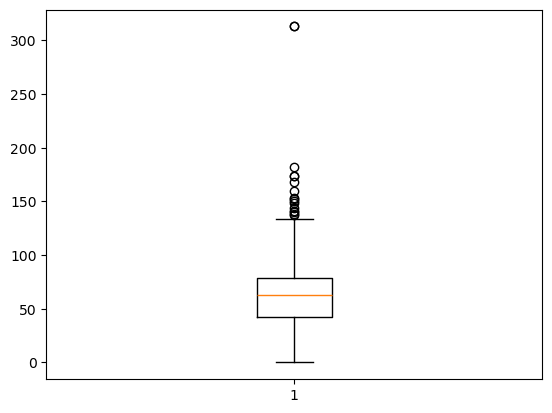

In [11]:
# Definimos la variable
LotFrontage = data["LotFrontage"]
# Vemos el tipo, los valores únicos y el valor min y max.
print(np.unique(LotFrontage))
print(f"Tipo:{LotFrontage.dtype}")
print(f"Mínimo:{LotFrontage.min()}\nMáximo:{LotFrontage.max()}")
# Comprobamos si tiene valores nulos
if LotFrontage.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    
# Sustituimos Nan por 0 y vemos los outliers con boxplot
LotFrontage.fillna(0, inplace=True)
plt.boxplot(LotFrontage)
plt.show()

Esta variable indica la distancia en pies desde la calle hasta la vivienda. Es una variable numérica. Simplemente, dice la distancia en un tipo de unidades. El máximo es 313 pies y su mínimo 21 pies(En cuanto a valores disponibles).Tiene valores nulos, esto lo podemos ver tanto en los valores únicos como en la comprobación. Estos valores nulos no indican datos faltantes. Sabemos que hay en total 259 "Nan" debido al análisis de nulos que hemos hecho previamente. Estos "Nan" indican que no hay distancia entre la calle y la vivienda. Es decir, son adyacentes a la calle. Por tanto, son datos relevantes y vamos a codificarlos sustituyendo el "Nan" por 0. Para que así, nuestro modelo tenga todos los valores como numéricos y no figuren valores "Nan".

[  0.  21.  24.  30.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104.]
LotFrontage
0.0      259
60.0     143
70.0      70
80.0      69
50.0      57
        ... 
101.0      2
38.0       1
33.0       1
39.0       1
46.0       1
Name: count, Length: 77, dtype: int64
Mínimo:0.0
Máximo:104.0
No tiene valores nulos


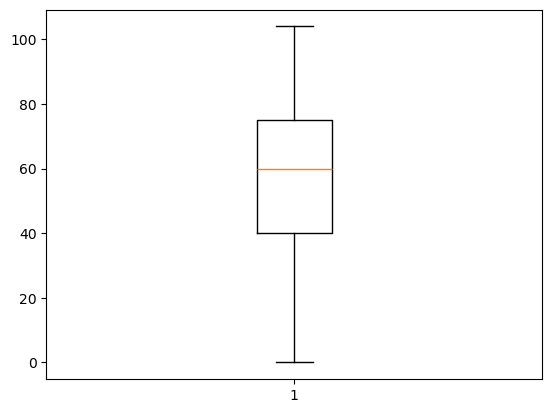

In [12]:
# Ahora que hemos codificado vamos a modificar los outliers mediante los cuantiles.
Q = data["LotFrontage"].quantile(0.95)
data = data[LotFrontage <= Q]
# Redefinimos la variable
LotFrontage = data["LotFrontage"]
print(np.unique(LotFrontage))
print(LotFrontage.value_counts())
print(f"Mínimo:{LotFrontage.min()}\nMáximo:{LotFrontage.max()}")

if LotFrontage.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    

# Vamos a ver si hay outliers
plt.boxplot(LotFrontage)
plt.show()

Ahora, vemos como el valor mínimo es 0, no hay valores nulos y como el valor 0 es el que más se repite. Es decir, hay más viviendas adyacentes a la calle. Además, hemos eliminado los outliers, en este caso los valore por encima del cuantil 0.95. Es decir, hemos eliminado el 5% de los datos que superan dicho cuantil. Con esto nos aseguramos que no haya outliers. No lo hacemos también por abajo por lo anterior mencionado y porque lo podemos ver en el boxplot. Ahora el máximo es 104, hay menos valores únicos y nos ha resultado en un nuevo dataset de 1318 datos.
### LotArea

[  1300   1477   1491 ... 115149 159000 164660]
Mínimo:1300
Máximo:164660
No tiene valores nulos
LotArea
7200     25
9600     23
6000     17
8400     14
9000     14
         ..
9803      1
9170      1
15602     1
7596      1
9717      1
Name: count, Length: 1007, dtype: int64


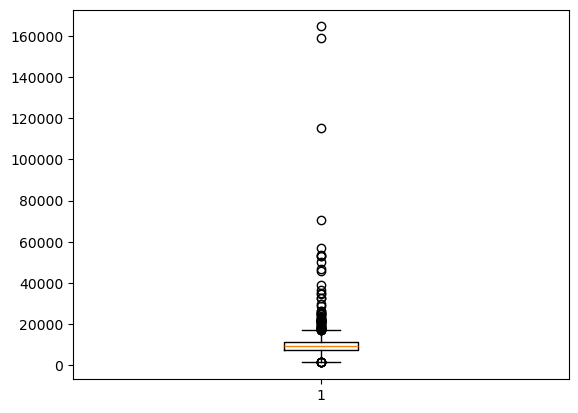

In [13]:
# Vamos a obtener la columna y a analizarla.
LotArea = data["LotArea"]
print(np.unique(LotArea))
print(f"Mínimo:{LotArea.min()}\nMáximo:{LotArea.max()}")
# Comprobamos si tiene valores nulos
if LotArea.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    
print(LotArea.value_counts())

# Usamos Boxplot para ver los outliers
plt.boxplot(LotArea)
plt.show()

Este atributo es de tipo numérico y tiene muchos valores únicos. Esta variable representa los pies cuadrados de un territorio. Es complicado que se repitan estos datos más de una vez. Aun así, vemos como hay algunos casos donde se repiten, suele coincidir cuando son números múltiplos o de 10 o de 100. No tiene valores nulos y su máximo es 215245 pies cuadrados y el mínimo 1300 pies cuadrados.

[ 3010  3013  3072  3136  3180  3182  3196  3230  3316  3363  3378  3500
  3600  3604  3635  3636  3675  3684  3696  3735  3842  3880  3922  3950
  3951  3964  3982  4017  4043  4045  4058  4060  4130  4224  4230  4251
  4270  4274  4280  4282  4388  4400  4403  4426  4435  4438  4456  4500
  4571  4590  4608  4671  4712  4750  4800  4920  4923  4928  5000  5001
  5062  5063  5100  5105  5119  5232  5250  5271  5306  5310  5330  5350
  5362  5381  5389  5395  5400  5436  5500  5520  5586  5587  5600  5604
  5664  5684  5687  5700  5720  5784  5790  5814  5820  5825  5868  5890
  5900  5925  6000  6040  6060  6120  6130  6155  6171  6173  6180  6204
  6240  6270  6292  6300  6305  6324  6342  6371  6380  6402  6420  6435
  6442  6563  6600  6627  6629  6762  6768  6780  6792  6820  6853  6858
  6882  6897  6900  6911  6930  6931  6951  6955  6960  6970  6979  6993
  7000  7015  7018  7024  7032  7050  7052  7056  7060  7064  7082  7094
  7100  7128  7134  7136  7150  7153  7162  7175  7

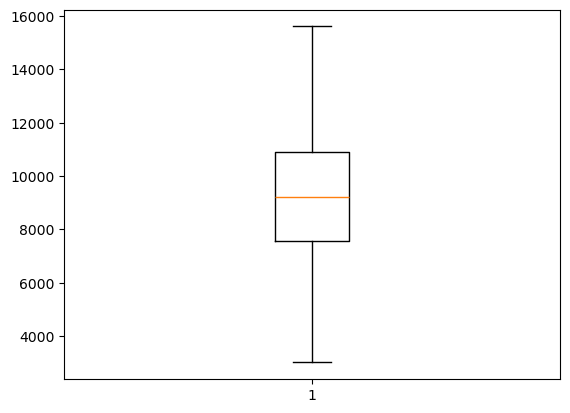

In [14]:
#  Tomamos únicamente los valores por debajo del 4% y los que están por encima del 94%. Así, nos aseguramos que no hay ningún outlier.
Q1 = data["LotArea"].quantile(0.94)
Q2 = data["LotArea"].quantile(0.04)
data = data[(LotArea <= Q1) & (LotArea >= Q2)] 
# Redefinimos la variable
LotArea = data["LotArea"]
print(np.unique(LotArea))
print(LotArea.value_counts())
print(f"Mínimo:{LotArea.min()}\nMáximo:{LotArea.max()}")

if LotArea.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    

# Vamos a ver si ya no hay outliers
plt.boxplot(LotArea)
plt.show()

Se ha eliminado un total del 10% del dataset. Ahora el modelo trabajará de una manera mucho más eficiente y eficaz. Ya que cuenta con menos datos y además trabaja con datos más cerca de la realidad. Ahora el máximo es de 15611 pies cuadrados y el mínimo de 3010. 
### Street

In [15]:
# Vamos a obtener la columna y a analizarla.
Street = data["Street"]
print(np.unique(Street))
print(Street.value_counts())
# Comprobamos si tiene valores nulos
if Street.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")
# Codificación booleana con map
data["Street"] = data["Street"].map({"Pave":True, "Grvl": False})

['Grvl' 'Pave']
Street
Pave    1246
Grvl       2
Name: count, dtype: int64
No tiene valores nulos


Este atributo es de tipo categórico y únicamente tiene dos valores posibles, o "Grvl" o "Pave". Street representa el tipo de material con el que está hecho el camino para acceder a la vivienda. En el análisis de la variable vemos como las calles pavimentadas abarcan la gran mayoría comparadas con las calles rellenas de grava, únicamente hay 6. No se puede visualizar el mínimo ni el máximo pero si podemos saber que más del 99% de los caminos están pavimentados(1454 Pave, 6 Grvl). Este atributo no tiene valores nulos. En este caso, dado que únicamente hay dos tipos vamos a codificar la variable de forma que "Pave" sea True y "Grvl" sea False debido a la gran cantidad de "Pave" que hay. Este atributo en el momento que pase a ser de tipo bool tendrá un mejor manejo para el modelo, ya que True o False se implementa de una forma más eficiente que con cadenas de caracteres. 

Al final vemos como el intérprete lo reconoce como tipo bool.
### Alley

In [16]:
Alley = data["Alley"]
# Vamos a utilizar la función unique de pandas en este caso
print(Alley.unique())
print(Alley.value_counts())
# Comprobamos si tiene valores nulos
if Alley.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")
# Sustituimos los valores nulos por un nuevo tipo de variable categórica
Alley.fillna("NoAlley", inplace=True)
# Ahora utilizamos OneHot Encoding y lo redefinimos en el dataset original
data = pd.get_dummies(data, columns=["Alley"])

[nan 'Grvl' 'Pave']
Alley
Grvl    48
Pave    34
Name: count, dtype: int64
El atributo tiene valores nulos


En el caso de Alley estamos ante un atributo de tipo categórico con una grandísima cantidad de valores nulos(más del 95%). Este atributo designa el tipo de material del callejon con el que se accede a la vivienda. En primer lugar, no se puede acceder a los valores mínimos y máximos, ya que es una variable categórica. En segundo lugar, vemos como hay más callejones con Grava que pavimentados pero no por una gran diferencia(Grvl 50, Pave 41). En tercer lugar, hay 3 tipos únicos con lo que no podemos convertirlo en un atributo bool. Que haya tantos valores nulos en este atributo lo que indica es que hay una gran cantidad de viviendas que no se acceden a ellas a través de callejones, no significa falta de datos. Por tanto, primero vamos a designar los valores nulos como que no hay callejon "NoAlley" y después vamos a hacer One-Hot Encoding como hemos hecho con todas las demás variables categóricas. Con esto conseguimos que el modelo analice mejor los datos.

Vamos a comprobarlo:

In [17]:
print(Alley.unique())
print(Alley.value_counts())
# Comprobamos si tiene valores nulos
if Alley.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")

['NoAlley' 'Grvl' 'Pave']
Alley
NoAlley    1166
Grvl         48
Pave         34
Name: count, dtype: int64
No tiene valores nulos


### LotShape

In [18]:
LotShape = data["LotShape"]
print(np.unique(LotShape))
print(LotShape.value_counts())
# Comprobamos si tiene valores nulos
if LotShape.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")
# OneHot Encoding para categóricas
data = pd.get_dummies(data, columns=["LotShape"])

['IR1' 'IR2' 'IR3' 'Reg']
LotShape
Reg    814
IR1    411
IR2     21
IR3      2
Name: count, dtype: int64
No tiene valores nulos


LotShape es un atributo que describe la forma del terreno de la vivenda. Es una variable categórica con orden porque cuanto más elevado sea la irregularidad más influencia puede tener en el precio de la misma. No tiene valores nulos y al ser categórico no podemos hallar su máximo ni su mínimo. Pero podemos saber que el que más se repite es Reg(872) y el que menos IR3(4). Tiene 4 valores únicos así que vamos a codificarlo con One Hot Encoding como hemos hecho con todas las demás. Hacemos esto para que las variables categóricas se codifiquen en columnas propias de tipo bool para que los modelos puedan procesarlas correctamente, manteniendo la información del atributo.
### LandContour

In [19]:
LandContour = data["LandContour"]
print(np.unique(LandContour))
print(LandContour.value_counts())
# Comprobamos si tiene valores nulos
if LandContour.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")
# OneHot Encoding para categóricas
data = pd.get_dummies(data, columns=["LandContour"])

['Bnk' 'HLS' 'Low' 'Lvl']
LandContour
Lvl    1139
Bnk      52
HLS      40
Low      17
Name: count, dtype: int64
No tiene valores nulos


LandContour es un atributo que indica lo plano que es el terreno de la vivenda. Es una variable categórica con orden porque dependiendo de lo plano que sea el terreno más influencia puede tener en el precio de la misma. No tiene valores nulos y al ser categórico no podemos hallar su máximo ni su mínimo. Pero podemos saber que el que más se repite es Lvl(1207) y el que menos Low(18). Tiene 4 valores únicos así que vamos a codificarlo con One Hot Encoding como hemos hecho con todas las demás. Hacemos esto para que las variables categóricas se codifiquen en columnas propias de tipo bool para que los modelos puedan procesarlas correctamente, manteniendo la información del atributo.
### Utilities

In [20]:
Utilities = data["Utilities"]
print(np.unique(Utilities))
print(Utilities.value_counts())
# Comprobamos si tiene valores nulos
if Utilities.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")
# Vamos a eliminar la instancia de Nosewa redefiniendo el dataset
data = data[data["Utilities"] == "AllPub"]
# y ahora eliminamos la columna  Utilities.
data = data.drop(columns=["Utilities"])
# Nos aseguramos
if "Utilities" in data.columns:
    print("No se ha eliminado")
else:
    print("Utilities ha sido eliminado correctamente")

['AllPub' 'NoSeWa']
Utilities
AllPub    1247
NoSeWa       1
Name: count, dtype: int64
No tiene valores nulos
Utilities ha sido eliminado correctamente


Este atributo de tipo categórico con orden, porque según la cantidad de utilidades el precio de la vivienda será menor o mayor. Como vemos solo tiene 2 valores únicos y de esos 2 valores parece ser que todos pertenecen al mismo atributo excepto 1. Si eliminamos ese instancia nos quedará una columna donde todos los valores son iguales. Eso no aporta información al modelo y lo único que hace es ocupar memoria. Por tanto, vamos a eliminar la columna de Utilities y la instancia que es diferente de las demás optimizando así la eficiencia del modelo.
### LandSlope

In [21]:
LandSlope = data["LandSlope"]
print(np.unique(LandSlope))
print(LandSlope.value_counts())
if LandSlope.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")

['Gtl' 'Mod' 'Sev']
LandSlope
Gtl    1197
Mod      47
Sev       3
Name: count, dtype: int64
No tiene valores nulos


LandSlope indica la pendiente que tiene el terreno de la vivienda. Es una variable de tipo categórico con orden, debido a que cuanto mayor sea la pendiente, mayor será la dificultad para acceder a ella y más segura será o más inconvenientes tendrá y por tanto influirá en el precio de una forma u otra.  No tiene valores nulos y tampoco cuenta con máximos ni con mínimos. Esta variable cuenta con 3 tipos únicos, siendo el más repetido Gtl(1266) y el que menos Sev(3). Esta vez no vamos a codificarlo usando One-Hot Encoding dado que más tarde vamos a analizarla gráficamente y hay que mantener la columna original. Estamos usando One-Hot Encoding en casi todas las variables debido a que son pocas columnas las que se añaden y la eficiencia y eficacia que genera para nuestro modelo, ya que así trabaja con datos booleanos y evita tener en cuenta tipos de variables. No tiene valores nulos y tampoco cuenta con máximos ni con mínimos.
### Neighborhood 

In [22]:
Neighborhood = data["Neighborhood"]
print(np.unique(Neighborhood))
print(Neighborhood.value_counts())
if Neighborhood.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")

['Blmngtn' 'BrkSide' 'ClearCr' 'CollgCr' 'Crawfor' 'Edwards' 'Gilbert'
 'IDOTRR' 'MeadowV' 'Mitchel' 'NAmes' 'NPkVill' 'NWAmes' 'NoRidge'
 'NridgHt' 'OldTown' 'SWISU' 'Sawyer' 'SawyerW' 'Somerst' 'StoneBr'
 'Timber' 'Veenker']
Neighborhood
NAmes      211
CollgCr    141
OldTown    107
Edwards     88
Somerst     73
Sawyer      68
Gilbert     65
NWAmes      64
BrkSide     57
SawyerW     56
NridgHt     55
Crawfor     40
Mitchel     40
IDOTRR      34
NoRidge     30
Timber      29
SWISU       24
StoneBr     21
Blmngtn     17
ClearCr     12
Veenker      8
NPkVill      4
MeadowV      3
Name: count, dtype: int64
No tiene valores nulos


Neighborhood es de tipo categórico sin orden, ya que lo único que hace es expresar el barrio donde se localiza la vivienda. Este atributo influye directamente en el precio de la vivienda, ya que la localización del inmueble influye en el precio. Vemos que el barrio donde más viviendas hay es NAmes(North Ames) y el que menos es Blueste(Bluestem). Vemos que hay muchos tipos de variables únicas . En este caso, tampoco vamos a utilizar one-hot encoding para codificar como en el anterior caso, debido a que vamos a analizarla gráficamente más tarde. Podría ser conveniente emplear una codificación alternativa (por ejemplo, target encoding) si el número de variables crece demasiado.
### YearBuilt y YearRemodAdd

[1872 1875 1880 1885 1890 1892 1893 1898 1900 1904 1905 1906 1908 1910
 1911 1912 1913 1914 1915 1916 1917 1918 1919 1920 1921 1922 1923 1924
 1925 1926 1927 1928 1929 1930 1931 1932 1934 1935 1936 1937 1938 1939
 1940 1941 1942 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955
 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969
 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983
 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010]
YearBuilt
2005    55
2006    53
2004    46
2007    44
2003    39
        ..
1906     1
1893     1
1908     1
1913     1
1905     1
Name: count, Length: 111, dtype: int64
Mínimo:1872
Máximo:2010
No tiene valores nulos


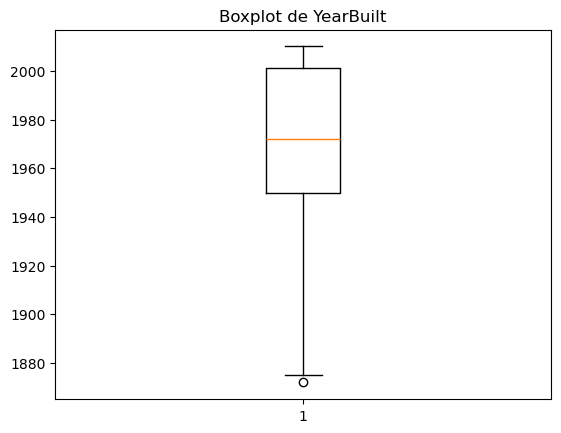

In [23]:
YearBuilt = data["YearBuilt"]
print(np.unique(YearBuilt))
print(YearBuilt.value_counts())
print(f"Mínimo:{YearBuilt.min()}\nMáximo:{YearBuilt.max()}")
if YearBuilt.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")
    
# Vamos a ver si hay outliers con un boxplot como hemos hecho anteriormente
plt.boxplot(data["YearBuilt"])
plt.title("Boxplot de YearBuilt")
plt.show()

Q = YearBuilt.quantile(0.01)
data = data[(YearBuilt >= Q)]

[1900 1904 1905 1906 1908 1910 1911 1912 1913 1914 1915 1916 1917 1918
 1919 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1945 1946 1947 1948 1949
 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010]
YearBuilt
2005    55
2006    53
2004    46
2007    44
2003    39
        ..
1913     1
1906     1
2010     1
1908     1
1905     1
Name: count, Length: 103, dtype: int64
Mínimo:1900
Máximo:2010
No tiene valores nulos


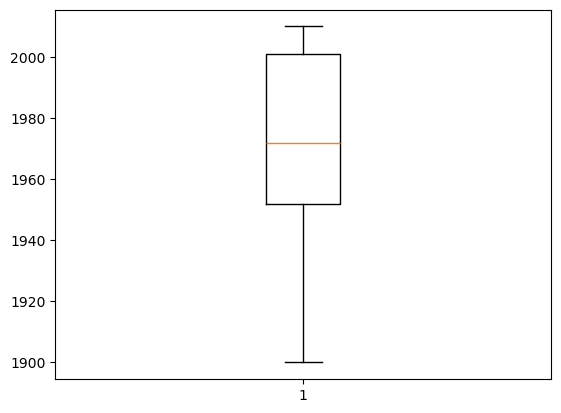

In [24]:
# Redefinimos la variable para ver si se ha modificado
YearBuilt = data["YearBuilt"]
print(np.unique(YearBuilt))
print(YearBuilt.value_counts())
print(f"Mínimo:{YearBuilt.min()}\nMáximo:{YearBuilt.max()}")

if YearBuilt.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    

# Vamos a ver si hay outliers
plt.boxplot(YearBuilt)
plt.show()

[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010]
YearRemodAdd
1950    166
2006     77
2007     67
2005     60
2004     54
       ... 
1952      5
1983      5
1974      5
1986      3
1951      3
Name: count, Length: 61, dtype: int64
Mínimo:1950
Máximo:2010
No tiene valores nulos


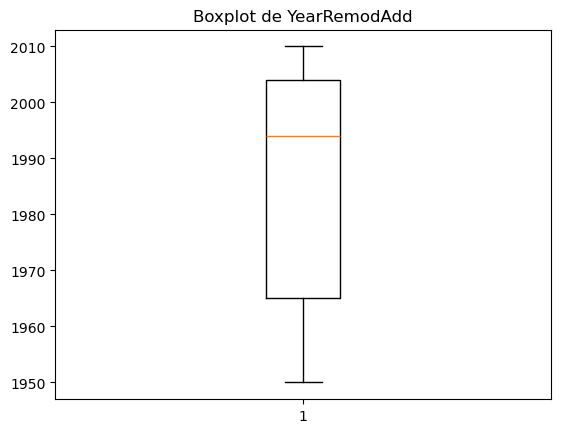

In [25]:
YearRemodAdd = data["YearRemodAdd"]
print(np.unique(YearRemodAdd))
print(YearRemodAdd.value_counts())
print(f"Mínimo:{YearRemodAdd.min()}\nMáximo:{YearRemodAdd.max()}")
if YearRemodAdd.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")
    
plt.boxplot(data["YearRemodAdd"])
plt.title("Boxplot de YearRemodAdd")
plt.show()

Estos dos atributos únicamente designan el año de construcción y de remodelación de una vivienda. En el caso de que la vivienda no ha sido remodelada se deja el año de construcción. Son de tipo numéricos, ya que designan el año cuando se construyo la casa, esto influye en el precio final, ya que cuanto más nueva sea una vivienda más nuevos serán los materiales y los muebles que vengan con ella y por ello el precio es mayor. No tiene valores nulos y  en cuanto al año de construcción el valor mínimo es 1872 y 1900 después de eliminar los outliers, el máximo 2010. Respecto a los años de remodelación el mínimo es 1950 y el máximo 2010. Como el máximo es 2010 en los dos eso quiere decir que si se verifica que si no ha sido remodelado se deja el año donde fue construida. No vamos a aplicar ninguna codificación. Podríamos sustituir el año de construcción por los años que tiene la vivienda en cuestión, o los años desde que fue remodelada. Para ver si hay outliers vamos a utilizar boxplots y vamos a eliminarlos como hemos hecho otras veces, redefiniendo la columna eliminándolos ya que supone una cantidad ínfima cogiendo el 1% del dataset. 
### Garage

In [26]:
# En primer lugar, vamos a definir todas las variables
Garage = ["GarageCars","GarageArea","GarageQual","GarageCond","GarageType","GarageYrBlt","GarageFinish"]
# El tipo de cada variable
for i in Garage:
    print(data[i].dtype)

'''
Valores nulos del ejercicio 3:

Atributo "GarageType", con valores Nulos 81
Atributo "GarageYrBlt", con valores Nulos 81
Atributo "GarageFinish", con valores Nulos 81
Atributo "GarageQual", con valores Nulos 81
Atributo "GarageCond", con valores Nulos 81
'''

int64
int64
object
object
object
float64
object


'\nValores nulos del ejercicio 3:\n\nAtributo "GarageType", con valores Nulos 81\nAtributo "GarageYrBlt", con valores Nulos 81\nAtributo "GarageFinish", con valores Nulos 81\nAtributo "GarageQual", con valores Nulos 81\nAtributo "GarageCond", con valores Nulos 81\n'

Vemos que dentro del atributo Garage hay varios atributos que designan cosas diferentes. GarageCars,GarageArea y GarageYrBlt son de tipo numérico. Cars designa el número de coches que caben; Area el número de pies cuadrados del garaje; YrBlt el año que fue construido. Por otra parte, GarageQual, GarageCond, GarageType y GarageFinsih son categóricos. Qual es una variable categórica con orden que define la calidad, cuanta más calidad mayor será el precio; Cond es un atributo categórico con orden que define la condición, cuanto mejor sea la condición mayor será el precio; Type es categórico sin orden, ya que deisgna el tipo de garaje; Por último, GarageFinish es una variable categórica con orden, ya que nos enseña si el garaje está terminado o sigue en construcción y eso influye. Vamos a trabajar primero con las de tipo numérico estudiando sus outliers y valores.

[2 3 1 0 4]
GarageCars
2    693
1    329
3    141
0     69
4      3
Name: count, dtype: int64
Mínimo:0
Máximo:4


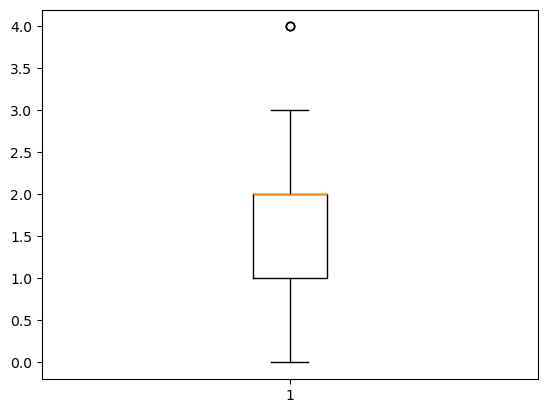

In [27]:
print(data["GarageCars"].unique())
print(data["GarageCars"].value_counts())
print(f"Mínimo:{data["GarageCars"].min()}\nMáximo:{data["GarageCars"].max()}")
plt.boxplot(data["GarageCars"])
plt.show()

[ 548  460  608  642  836  480  636  484  468  205  384  736  352  840
  576  516  294  853  280  534  572  270  772  240  250  271  447  556
  498  246    0  440  504  308  300  670  826  386  388  528  565  641
  288  645  852  558  220  667  360  427  490  379  283  509  405  758
  461  400  420  432  506  684  472  366  476  410  740  648  325  792
  180  430  594  390  264  530  453  750  487  624  471  318  766  660
  470  720  577  434  495  564  312  625  680  678  532  216  303  789
  616  521  451  252  497  682  666  786  856  473  398  500  349  454
  644  299  210  438  675  968  721  336  494  457  818  463  604  538
  520  309  429  673  868  492  413  924 1053  671  338  672  505  575
  626  898  529  281  418  588  282  539  552  888  708  546 1025  656
  872  292  441  189  880  676  297  431  301  617  445  200  592  514
  296  244  610  834  639  846  560  596  600  373  350  396  304  784
  696  569  628  550  493  198  422  513  228  526  866  525  499  508
  874 

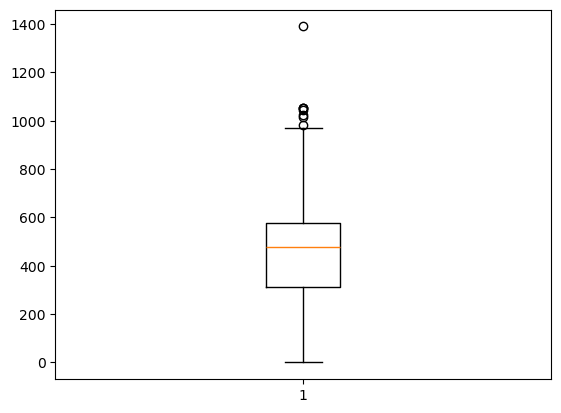

In [28]:
print(data["GarageArea"].unique())
print(f"Mínimo:{data["GarageArea"].min()}\nMáximo:{data["GarageArea"].max()}")
plt.boxplot(data["GarageArea"])
plt.show()

[2003. 1976. 2001. 1998. 2000. 1993. 2004. 1973. 1931. 1939. 1965. 2005.
 1962. 2006. 1960. 1991. 1970. 1967. 1958. 1930. 2002. 1968. 2008. 1920.
 1966. 2007. 1959. 1954. 1953.   nan 1983. 1977. 1997. 1985. 1964. 1935.
 1990. 1945. 1987. 1989. 1915. 1956. 1948. 1974. 1995. 2009. 1950. 1961.
 1921. 1900. 1999. 1979. 1951. 1963. 1936. 1971. 1923. 1984. 1926. 1955.
 1986. 1988. 1957. 1916. 1932. 1972. 1980. 1924. 1996. 1940. 1975. 1949.
 1994. 1910. 1978. 1981. 1982. 1992. 1925. 1941. 2010. 1927. 1947. 1937.
 1942. 1938. 1952. 1928. 1922. 1934. 1969. 1906. 1914. 1946. 1929. 1933.]
GarageYrBlt
2005.0    58
2004.0    45
2006.0    45
2003.0    43
2007.0    42
          ..
1937.0     1
1900.0     1
1915.0     1
1906.0     1
1933.0     1
Name: count, Length: 95, dtype: int64
Mínimo:1900.0
Máximo:2010.0


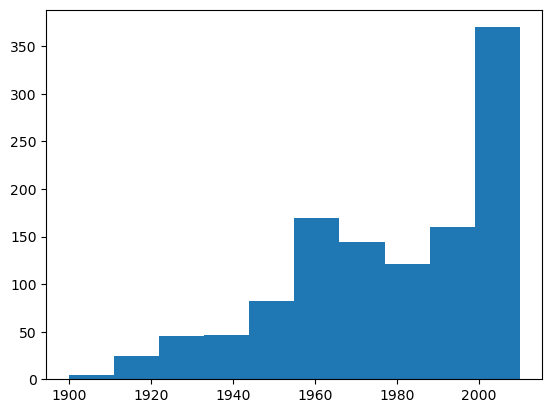

In [29]:
print(data["GarageYrBlt"].unique())
print(data["GarageYrBlt"].value_counts())
print(f"Mínimo:{data["GarageYrBlt"].min()}\nMáximo:{data["GarageYrBlt"].max()}")
plt.hist(data["GarageYrBlt"])
plt.show()

GarageArea
0      69
576    40
240    37
440    36
484    31
       ..
320     1
325     1
831     1
740     1
192     1
Name: count, Length: 383, dtype: int64
Mínimo:0
Máximo:928


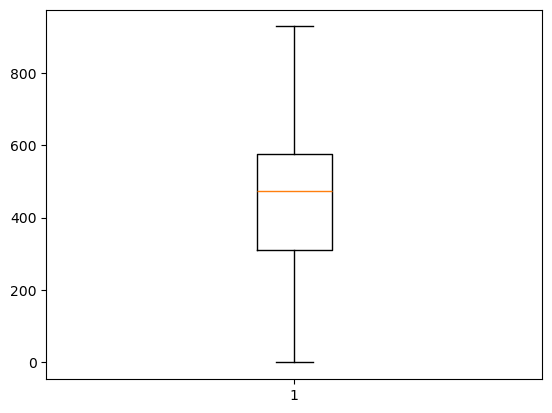

In [30]:
# Calculamos el cuantil y redefinimos la variable
Q = data["GarageArea"].quantile(0.99)
data = data[(data["GarageArea"] <= Q)]
# Comprobamos
print(data["GarageArea"].value_counts())
print(f"Mínimo:{data["GarageArea"].min()}\nMáximo:{data["GarageArea"].max()}")
plt.boxplot(data["GarageArea"])
plt.show()

La variable Cars, podemos ver en Boxplot como los garajes de 4 plazas las considera como outliers. Aun así, no vamos a eliminar los outliers porque puede ser posible que haya garajes de 4 plazas, tampoco vamos a codificar esta variable. Su valor máximo es de 4 y su mínimo es de 0 y no tiene valores nulos y para ser de tipo numérico tiene pocos valores únicos. 

El atributo Area cuenta con muchos valores únicos (383) y vemos también que hay bastante outliers por encima. Vamos a elimarlos usando los cuantiles como de costumbre, vamos a coger únicamente un 1% aunque sobren outliers para no modificar demasiado el dataset original. El valor máximo es 1390 antes de modificar el dataset y de 928 despues de modificar el dataset. El mínimo es 0 para aquellas viviendas que no tienen garaje. No tiene valores nulos ya que están sustituidos por 0.

GarageYrBlt en primer lugar tiene los datos de tipo float, por tanto el boxplot no lo reconoce. Para ello vamos a modificar los datos convirtiendolos en int. Tiene valores nulos para aquellas viviendas que no cuentan con garajes, el máximo es 2010 y el mínimo 1900. Visualizando un histograma no vemos ningún outlier. 

Ahora, antes de seguir con las siguientes columnas vamos a crear una nueva. Se va a denominar "HasGarage". Con esta variable podemos quitar los valores nulos de los demás atributos y así podemos tener una variable booleana con la que se sepa si la vivienda tiene o no garaje. A su vez en las variables donde hay valores nulos los mmodificamos por "NoGarage".

In [31]:
# Creamos la nueva columna
# notna serviría con cualquier otra variable de garage que tenga nulos
data["HasGarage"] = data["GarageYrBlt"].notna()
# Ahora modificamos los valores nulos
data["GarageYrBlt"].fillna(0, inplace = True)
print(data["GarageYrBlt"].unique())
for i in Garage: 
    if data[i].dtype == "object":
        data[i].fillna("NoGarage", inplace=True)
# Vamos a comprobarlo con el código del ejercicio 3
print(data["HasGarage"].value_counts())
print(data["GarageFinish"].value_counts())
for i in data:
    if data[[i]].isnull().sum()[i]> 0:
        print(f'Atributo "{i}", con valores Nulos {data[[i]].isnull().sum()[i]}')

[2003. 1976. 2001. 1998. 2000. 1993. 2004. 1973. 1931. 1939. 1965. 2005.
 1962. 2006. 1960. 1991. 1970. 1967. 1958. 1930. 2002. 1968. 2008. 1920.
 1966. 2007. 1959. 1954. 1953.    0. 1983. 1977. 1997. 1985. 1964. 1935.
 1990. 1945. 1987. 1989. 1915. 1956. 1948. 1974. 1995. 2009. 1950. 1961.
 1921. 1900. 1999. 1979. 1951. 1963. 1936. 1971. 1923. 1984. 1926. 1955.
 1986. 1988. 1957. 1916. 1932. 1972. 1980. 1924. 1996. 1940. 1975. 1949.
 1994. 1910. 1978. 1981. 1982. 1992. 1925. 1941. 2010. 1927. 1947. 1937.
 1942. 1938. 1952. 1928. 1922. 1934. 1969. 1906. 1914. 1946. 1929. 1933.]
HasGarage
True     1153
False      69
Name: count, dtype: int64
GarageFinish
Unf         511
RFn         359
Fin         283
NoGarage     69
Name: count, dtype: int64
Atributo "MasVnrType", con valores Nulos 741
Atributo "MasVnrArea", con valores Nulos 6
Atributo "BsmtQual", con valores Nulos 35
Atributo "BsmtCond", con valores Nulos 35
Atributo "BsmtExposure", con valores Nulos 36
Atributo "BsmtFinType1", con v

/tmp/ipykernel_7284/1364433931.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["GarageYrBlt"].fillna(0, inplace = True)
/tmp/ipykernel_7284/1364433931.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [32]:
print(data["GarageQual"].unique())
print(data["GarageQual"].value_counts())
data = pd.get_dummies(data, columns=["GarageQual"])

['TA' 'Fa' 'Gd' 'NoGarage' 'Po' 'Ex']
GarageQual
TA          1097
NoGarage      69
Fa            41
Gd            10
Po             3
Ex             2
Name: count, dtype: int64


In [33]:
print(data["GarageCond"].unique())
print(data["GarageCond"].value_counts())
data = pd.get_dummies(data, columns=["GarageCond"])

['TA' 'Fa' 'NoGarage' 'Gd' 'Po' 'Ex']
GarageCond
TA          1106
NoGarage      69
Fa            32
Gd             8
Po             5
Ex             2
Name: count, dtype: int64


In [34]:
print(data["GarageType"].unique())
print(data["GarageType"].value_counts())
data = pd.get_dummies(data, columns=["GarageType"])

['Attchd' 'Detchd' 'BuiltIn' 'CarPort' 'NoGarage' 'Basment' '2Types']
GarageType
Attchd      727
Detchd      338
NoGarage     69
BuiltIn      66
Basment      12
CarPort       6
2Types        4
Name: count, dtype: int64


In [35]:
print(data["GarageFinish"].unique())
print(data["GarageFinish"].value_counts())
data = pd.get_dummies(data, columns=["GarageFinish"])

['RFn' 'Unf' 'Fin' 'NoGarage']
GarageFinish
Unf         511
RFn         359
Fin         283
NoGarage     69
Name: count, dtype: int64


Con las variables categóricas vamos a apicar one-hot encoding para que nuestro modelo tenga una mejor gestión de los datos aportados. Ahora, ninguna variable de Garage tiene valores nulos. Al ser variables categóricas no se pueden ver ni sus máximos ni sus mínimos. En todas las variables se repiten los mismos 69 NoGarage. Eso nos confirma que hemos codificado de una manera correcta.
### OverallQual y OverallCond

In [36]:
# Vamos a obtener la columna y a analizarla.
OverallQual = data["OverallQual"]
print(np.unique(OverallQual))
print(f"Mínimo:{OverallQual.min()}\nMáximo:{OverallQual.max()}")
# Comprobamos si tiene valores nulos
if OverallQual.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    
print(OverallQual.value_counts())

[ 1  2  3  4  5  6  7  8  9 10]
Mínimo:1
Máximo:10
No tiene valores nulos
OverallQual
5     348
6     314
7     269
8     138
4      97
9      28
3      16
10      7
2       3
1       2
Name: count, dtype: int64


In [37]:
# Vamos a obtener la columna y a analizarla.
OverallCond = data["OverallCond"]
print(np.unique(OverallCond))
print(f"Mínimo:{OverallCond.min()}\nMáximo:{OverallCond.max()}")
# Comprobamos si tiene valores nulos
if OverallCond.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    
print(OverallCond.value_counts())

[1 2 3 4 5 6 7 8 9]
Mínimo:1
Máximo:9
No tiene valores nulos
OverallCond
5    682
6    218
7    178
8     63
4     41
3     20
9     15
2      4
1      1
Name: count, dtype: int64


OverallQual es un atributo de tipo categórico con orden, debido a que únicamente expresa la nota del 1 al 10 de la cualidad de los materiales y del terminado de la vivienda. No hay valores nulos, se puede decir que en este caso el valor máximo es 10 y el mínimo 1. No vamos a codifcar esta variable ya que no hace falta, tampoco vamos a eliminarla. Aporta información de la cualidad de los materiales, por tanto es necesario para el modelo. Se puede decir la misma información acerca de OverallCond. La única diferencia es que en este caso valora la condición general de la vivienda del 1 al 10.
### SalePrice

[ 34900  35311  37900  39300  40000  52000  55000  55993  58500  60000
  61000  62383  64500  66500  67000  68400  68500  72500  73000  76000
  76500  78000  79000  79500  79900  80000  80500  81000  82000  82500
  83000  84000  84500  84900  85000  85500  86000  87000  87500  88000
  89000  89471  89500  90000  90350  91000  91300  91500  92900  93000
  93500  94750  95000  96500  97000  98000  98300  98600  99500  99900
 100000 101000 101800 102000 102776 103000 103200 103600 104000 104900
 105000 105500 105900 106250 106500 107000 107400 107500 107900 108000
 108480 108500 108959 109000 109008 109500 109900 110000 110500 111000
 111250 112000 112500 113000 114500 114504 115000 116000 116050 116500
 116900 117000 117500 118000 118400 118500 118858 118964 119000 119200
 119500 119750 119900 120000 120500 121000 121500 121600 122000 122900
 123000 123500 123600 124000 124500 124900 125000 125500 126000 126175
 126500 127000 127500 128000 128200 128500 128900 128950 129000 129500
 12990

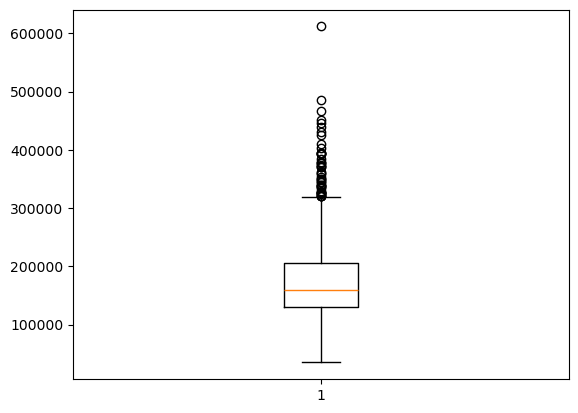

In [38]:
# Vamos a obtener la columna y a analizarla.
SalePrice = data["SalePrice"]
print(np.unique(SalePrice))
print(f"Mínimo:{SalePrice.min()}\nMáximo:{SalePrice.max()}")
# Comprobamos si tiene valores nulos
if SalePrice.isna().any():
    print("El atributo tiene valores nulos")
else:
    print("No tiene valores nulos")    
print(SalePrice.value_counts())
# Vamos a ver si hayn outliers
plt.boxplot(SalePrice)
plt.show()

SalePrice es la variable que más nos interesa hasta este momento, designa el precio final al que se ha vendido una vivienda. Con boxplot vemos como hay outliers, aun así no los vamos a modifiar porque es el atributo final y el que más nos interesa y todo dato recogido es vital para el modelo. No hay valores nulos, el máximo es 611657 dolares y el mínimo 34900 dolares. Dispone de muchísimo valores únicos este atributo numérico. En conclusión, no vamos a modificar la variable, ya que según como la modifiquemos el modelo varaiará bastante.
### Ejercicio 5

In [39]:
missingA = dolo.isnull().sum()
missingD = data.isnull().sum()
cols = []
missA = []
missD = []

for i in data.columns:
    antes = missingA[i] if i in missingA.index else 0  # Si no existía, 0
    despues = missingD[i]
    cols.append(i)
    missA.append(antes)
    missD.append(despues)

tabla = pd.DataFrame({
    'Columna': cols,
    '#Missing values antes': missA,
    '#Missing values (ahora)': missD
}).sort_values(by='#Missing values antes', ascending=False)

tabla

,Columna,#Missing values antes,#Missing values (ahora)
62,PoolQC,1453,1220
64,MiscFeature,1406,1174
63,Fence,1179,965
19,MasVnrType,872,741
51,FireplaceQu,690,607
...,...,...,...
42,BsmtHalfBath,0,0
41,BsmtFullBath,0,0
40,GrLivArea,0,0
39,LowQualFinSF,0,0


Las variables categóricas que originalmente presentaban una gran cantidad de valores nulos (PoolQC, MiscFeature, Alley, Fence, MasVnrType, entre otras) ya no contienen valores faltantes, ya que al ser transformadas mediante One-Hot Encoding sus valores NaN se reemplazaron por ceros en las columnas dummy correspondientes

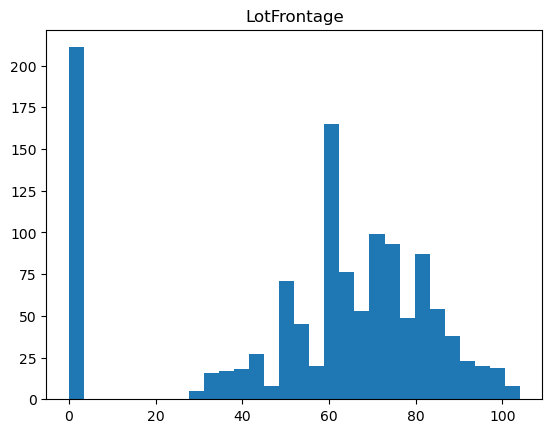

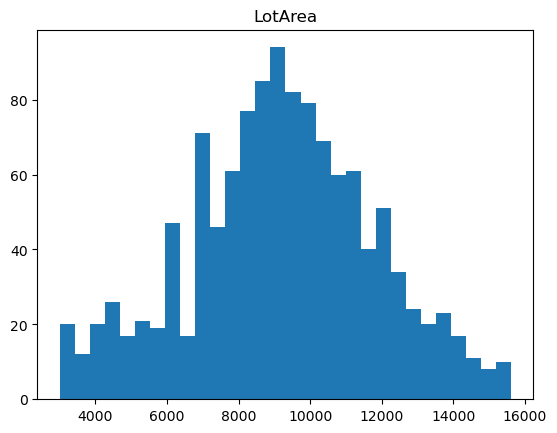

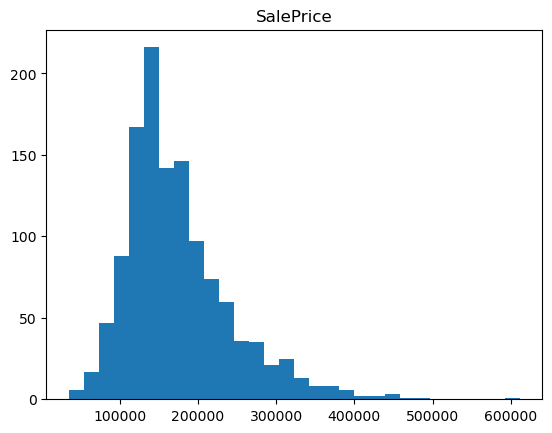

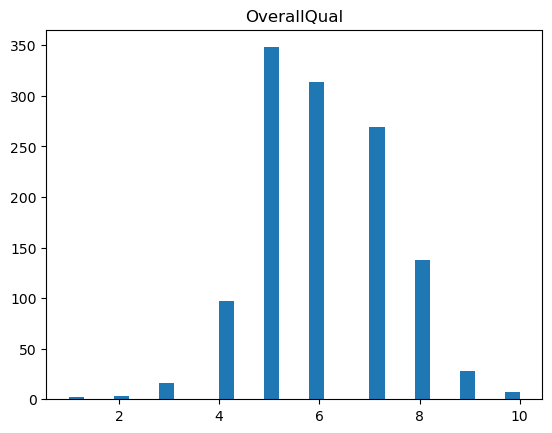

In [40]:
plt.hist(data['LotFrontage'].dropna(), bins=30)
plt.title('LotFrontage')
plt.show()

plt.hist(data['LotArea'].dropna(), bins=30)
plt.title('LotArea')
plt.show()

plt.hist(data['SalePrice'].dropna(), bins=30)
plt.title('SalePrice')
plt.show()

plt.hist(data['OverallQual'].dropna(), bins=30)
plt.title('OverallQual')
plt.show()

LotFrontage esta centrada aprox en 60–80, con cola derecha y algunos valores extremos(posibles outliers)


LotArea muy sesgada a la derecha con outliers de parcelas enormes. La masa está en lotes relativamente pequeños


SalePrice sesgo a la derecha: la mayoría entre 120 y 220k con pocas viviendas muy caras que generan cola larga.


OverallQual es una distribución discreta concentrada en 5–7 Muy pocas casas en valores extremos. esto demuestra una calidad media-buena


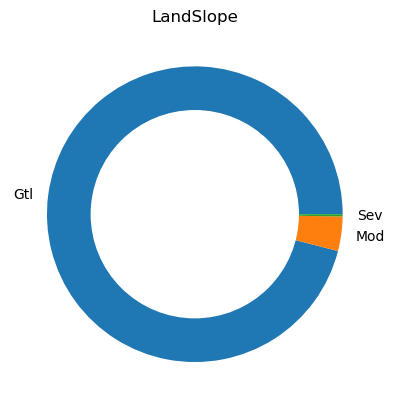

In [41]:
cnt = data['LandSlope'].value_counts()
plt.pie(cnt.values, labels=cnt.index)
my_circle = plt.Circle((0,0), 0.7, color='white')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title('LandSlope')
plt.show()

LandSlope: Dominada por Gtl; casi no hay Mod ni Sev, osea que es una variable desbalanceada. Esto indica la pendiente del solar; lo habitual son terrenos casi planos.


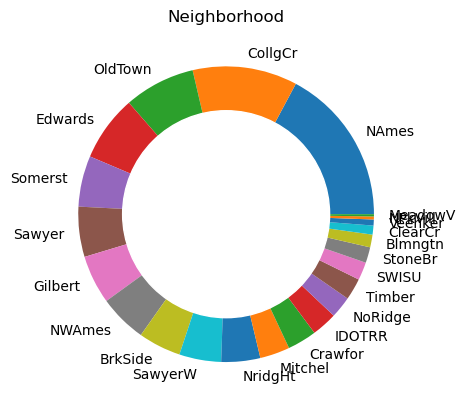

In [42]:
cnt = data['Neighborhood'].value_counts()
plt.pie(cnt.values, labels=cnt.index)
my_circle = plt.Circle((0,0), 0.7, color='white')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title('Neighborhood')
plt.show()

Neighborhood: Alto desbalanceo: destacan NAmes, CollgCr, OldTown y muchas categorías pequeñas. Simplemente representa el prestigio de cada zona.

Que le haria a las variables?
LotArea y SalePrice: muy sesgadas, osea que aplicar log, y capar outliers.
LotFrontage: imputar por mediana del barrio, revisar outliers y, si queda sesgo, log.
Neighborhood: one-hot agrupando categorías poco frecuentes en Other.

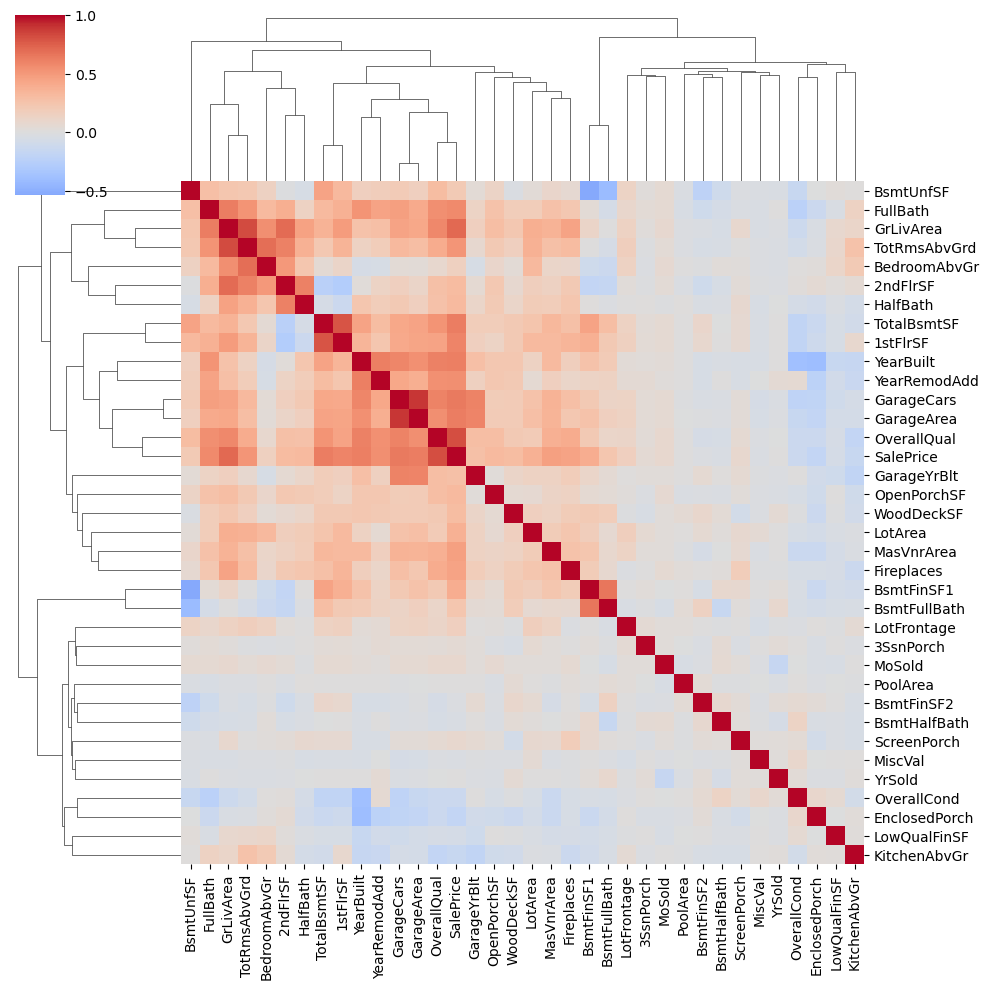

In [43]:
num = data.select_dtypes(include=[np.number]).drop(columns=['Id'], errors='ignore')
corr = num.corr()
sn.clustermap(corr, cmap='coolwarm', center=0)
plt.show()

El precio sube sobre todo con calidad global, superficie habitable y tamaño del garaje/sótano.Ahí es donde encontramos mas correlación. 
Garaje: GarageCars y GarageArea son muy colineales.
Son los valores principales que afectan a precio.